<a href="https://colab.research.google.com/github/snamazova/centaur_evaluation/blob/main/rescorla_wagner_simplified.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import io
import random
import numpy as np
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
random.seed(42)

# Number of trials
num_trials = 100

# Define the timeline
timeline = []
for i in range(num_trials):
    while True:
        if i < (num_trials / 2):
            bandit_1_reward = random.choices([1, 0], weights=[0.8, 0.2])[0]
            bandit_2_reward = random.choices([1, 0], weights=[0.2, 0.8])[0]
        else:
            bandit_1_reward = random.choices([1, 0], weights=[0.2, 0.8])[0]
            bandit_2_reward = random.choices([1, 0], weights=[0.8, 0.2])[0]

        if not (bandit_1_reward == 0 and bandit_2_reward == 0):
            break

    timeline.append({
        "bandit_1": {"color": "orange", "value": bandit_1_reward},
        "bandit_2": {"color": "blue", "value": bandit_2_reward}
    })

In [ ]:
def parse_timeline(timeline):
    rewards_per_trial = []
    for trial in timeline:
        # Extract rewards for bandit_1 and bandit_2
        reward_1 = trial['bandit_1']['value']
        reward_2 = trial['bandit_2']['value']
        rewards_per_trial.append([reward_1, reward_2])
    return rewards_per_trial

In [ ]:
# Parse the timeline
rewards_per_trial = parse_timeline(timeline)

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
class RWModel:
    def __init__(self, N, alpha, theta, d):
        self.N = N                      # number of bandits
        self.alpha = alpha              # learning rate (can be raw, will use sigmoid)
        self.theta = theta
        self.d=d
        self.V = np.full(N, d)  # value estimates

    def choose(self):
        z = self.theta * self.V
        exp_z = np.exp(z - np.max(z))   # softmax for stability
        p = exp_z / np.sum(exp_z)
        return np.random.choice(self.N, p=p)
    def action_probs(self):
        z = self.theta * self.V
        exp_z = np.exp(z - np.max(z))
        return exp_z / exp_z.sum()

    def update(self, c_t, r_t):
        delta = r_t - self.V[c_t]
        #lr = sigmoid(self.alpha)        # use bounded learning rate
        self.V[c_t] += self.alpha * delta


In [ ]:
def generate_seeds(num_seeds=20, seed=42):
    """Generates a list of random seeds.

    Args:
        num_seeds: The number of seeds to generate.
        seed: The initial seed for the random number generator (for reproducibility).

    Returns:
        A list of random integer seeds.
    """
    random.seed(seed)  # Set initial seed for reproducibility
    seeds = [random.randint(1, 100000) for _ in range(num_seeds)]
    return seeds

In [ ]:
seeds=generate_seeds(num_seeds=32)

In [ ]:
# Lists to store data for DataFrame
trials = []
choices = []
rewards = []
cumulative_rewards = []
total_reward = 0
alpha=0.5
theta=2.5
d=0.5
true_params=[alpha,theta,d]
N=2
model_ids=[]
seeds_test=[42]
# Run the simulation
for seed in enumerate(seeds):
    m=seed[1]
    np.random.seed(m)  # Change NumPy random seed
    random.seed(m)  # Change Python random seed

    model = RWModel(N,*true_params)  # Re-initialize the model
    total_reward = 0

    for t in range(len(rewards_per_trial)):
        c_t = model.choose()
        r_t = rewards_per_trial[t][c_t]  # Get reward for chosen bandit
        trials.append(t + 1)  # Trial number starting from 1
        choices.append(c_t)
        rewards.append(r_t)
        total_reward += r_t
        cumulative_rewards.append(total_reward)
        model.update(c_t, r_t)
        model_ids.append(m)

    print(f"Model ID {m}, Cumulative Reward {total_reward}")

Model ID 83811, Cumulative Reward 85
Model ID 14593, Cumulative Reward 82
Model ID 3279, Cumulative Reward 84
Model ID 97197, Cumulative Reward 81
Model ID 36049, Cumulative Reward 85
Model ID 32099, Cumulative Reward 87
Model ID 29257, Cumulative Reward 81
Model ID 18290, Cumulative Reward 83
Model ID 96531, Cumulative Reward 87
Model ID 13435, Cumulative Reward 82
Model ID 88697, Cumulative Reward 85
Model ID 97081, Cumulative Reward 85
Model ID 71483, Cumulative Reward 83
Model ID 11396, Cumulative Reward 86
Model ID 77398, Cumulative Reward 88
Model ID 55303, Cumulative Reward 87
Model ID 4166, Cumulative Reward 87
Model ID 3906, Cumulative Reward 84
Model ID 12281, Cumulative Reward 85
Model ID 28658, Cumulative Reward 77
Model ID 30496, Cumulative Reward 84
Model ID 66238, Cumulative Reward 83
Model ID 78908, Cumulative Reward 82
Model ID 3479, Cumulative Reward 77
Model ID 73564, Cumulative Reward 83
Model ID 26063, Cumulative Reward 88
Model ID 93851, Cumulative Reward 85
Model

In [ ]:
sim_df = pd.DataFrame({
    'trial': trials,
    'choice': choices,
    'reward': rewards,
    'cumulative_reward': cumulative_rewards,
    'model_id': model_ids
})

In [ ]:
def nll_rw_single(params, df, N):
    """
    params : length-6 arraylike of *raw* (unconstrained) values
             [α⁺_raw, α⁻_raw, a_raw, b_raw, c_raw, d]
    df     : DataFrame with at least 'choice' and 'reward' columns
    N      : number of arms
    """
    model = RWModel(N, *params)
    loglik = 0.0

    for _, row in df.iterrows():
        #trial_type = row['trial_type']
        choice, reward = int(row['choice']), row['reward']
            # log P(choice_t)
        log_p = np.log(model.action_probs()[choice] + 1e-12)
        loglik += log_p
        #print(loglik)

        # state update
        model.update(choice, reward)

    return -loglik          # minimise NLL

In [ ]:
from scipy.optimize import minimize

def fit_rw_model(df, initial_guesses=None):
    if initial_guesses is None:
        initial_guesses = [
            [0.5, 2.5,0.5],    # Example initial guess 1
            [0.8, 7.0,0.8],    # Example initial guess 2
            [0.3, 2.0,0.3],    # Example initial guess 3
        ]

    bounds = [
        (0, 1),          # alpha
        (0, 10),         # theta
        (0, 10)          # d
    ]

    best_result = None
    best_loss = float('inf')
    N=2

    for guess in initial_guesses:
        result = minimize(
            nll_rw_single,
            x0=guess,
            args=(df, N),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if result.success and result.fun < best_loss:
            best_result = result
            best_loss = result.fun

    if best_result is None:
        raise ValueError("Optimization failed with all initial guesses.")

    return best_result.x, best_result

In [ ]:
fitted_params=fit_rw_model(sim_df,[true_params])
param_names=['alpha','theta','d']

In [ ]:
fitted_params

(array([0.60599195, 2.21771132, 4.6903555 ]),
   message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: 1361.0198180187288
         x: [ 6.060e-01  2.218e+00  4.690e+00]
       nit: 16
       jac: [ 4.547e-05 -2.888e-03  9.095e-05]
      nfev: 80
      njev: 20
  hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>)

In [ ]:
import matplotlib.pyplot as plt

def plot_parameter_comparison(true_params, fitted_params, param_names):
    """
    Plots a comparison between true and fitted parameters.

    Args:
        true_params: A list or array of true parameter values.
        fitted_params: A list or array of fitted parameter values.
        param_names: A list of parameter names.
    """

    plt.figure(figsize=(6, 6))
    plt.scatter(true_params, fitted_params, c='blue')
    plt.plot(true_params, true_params, 'k--', label='Perfect Fit')

    for i, name in enumerate(param_names):
        plt.annotate(name, (true_params[i], fitted_params[i]), textcoords="offset points", xytext=(5, 5), ha='left')

    plt.xlabel('True Parameters')
    plt.ylabel('Fitted Parameters')
    plt.title('True vs. Fitted Parameters Simplified RW')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

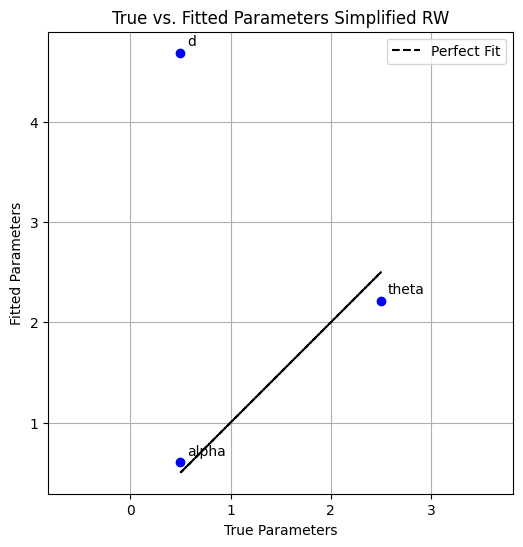

In [ ]:
plot_parameter_comparison(true_params, fitted_params[0], param_names)

In [ ]:
val_negLL = nll_rw_single(fitted_params[0], sim_df,N)
print("Validation NLL:", val_negLL)

Validation NLL: 1361.0198180187288


In [ ]:
print("Average log loss per trial:", val_negLL / len(sim_df))

Average log loss per trial: 0.42531869313085274


In [ ]:
import json
# Create a dictionary to hold the metrics
metrics = {
    'validation_nll': val_negLL,
    'average_log_loss_per_trial': val_negLL / len(sim_df)
}

# Specify a filename for the output (e.g., JSON)
output_filename = '/content/drive/MyDrive/centaur/reversal_learning/rw_model_metrics.json'

# Save the metrics to a JSON file
with open(output_filename, 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"Metrics saved to {output_filename}")

Metrics saved to /content/drive/MyDrive/centaur/reversal_learning/rw_model_metrics.json


In [ ]:
#@title generalisation

In [ ]:
sim_df.to_csv('/content/drive/MyDrive/centaur/reversal_learning/rw_reversal_learning.csv', index=False)